## Importing the dependencies

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import *
import joblib
import seaborn as sns

## Data Collection and Preprocessing

In [2]:
# Loading the dataset
data_path=Path("../data/kidney_disease.csv")
kd=pd.read_csv(data_path)

In [3]:
kd['Target'].unique()

array(['No_Disease', 'Low_Risk', 'Moderate_Risk', 'Severe_Disease',
       'High_Risk'], dtype=object)

In [4]:
# Printing the first 5 rows of the dataset
kd.head()

,Age of the patient,Blood pressure (mm/Hg),Specific gravity of urine,Albumin in urine,Sugar in urine,Red blood cells in urine,Pus cells in urine,Pus cell clumps in urine,Bacteria in urine,Random blood glucose level (mg/dl),...,Smoking status,Body Mass Index (BMI),Physical activity level,Duration of diabetes mellitus (years),Duration of hypertension (years),Cystatin C level,Urinary sediment microscopy results,C-reactive protein (CRP) level,Interleukin-6 (IL-6) level,Target
0,54,167,1.023,1,4,normal,abnormal,not present,not present,96,...,yes,25.3,low,4,16,0.67,normal,4.88,10.23,No_Disease
1,42,127,1.023,3,2,normal,normal,not present,present,73,...,no,20.6,moderate,3,13,0.55,abnormal,4.49,13.11,Low_Risk
2,38,148,1.016,0,0,abnormal,normal,not present,not present,77,...,no,38.4,high,11,23,2.37,abnormal,4.57,13.27,No_Disease
3,7,98,1.017,4,0,abnormal,normal,not present,present,225,...,no,24.7,high,24,3,2.54,abnormal,8.57,12.36,No_Disease
4,67,174,1.015,1,1,normal,abnormal,not present,not present,376,...,yes,17.6,high,22,24,1.90,normal,6.75,1.46,No_Disease


In [5]:
# Printing the last 5 rows of the dataset
kd.tail()

,Age of the patient,Blood pressure (mm/Hg),Specific gravity of urine,Albumin in urine,Sugar in urine,Red blood cells in urine,Pus cells in urine,Pus cell clumps in urine,Bacteria in urine,Random blood glucose level (mg/dl),...,Smoking status,Body Mass Index (BMI),Physical activity level,Duration of diabetes mellitus (years),Duration of hypertension (years),Cystatin C level,Urinary sediment microscopy results,C-reactive protein (CRP) level,Interleukin-6 (IL-6) level,Target
20533,86,113,1.008,5,3,normal,abnormal,not present,not present,473,...,no,38.2,low,25,1,2.77,normal,2.45,9.31,No_Disease
20534,47,80,1.016,3,4,normal,abnormal,not present,not present,477,...,no,26.8,moderate,3,7,1.81,normal,4.19,3.45,No_Disease
20535,89,178,1.011,3,5,abnormal,abnormal,not present,not present,141,...,yes,30.0,low,6,25,1.32,abnormal,5.32,8.39,No_Disease
20536,86,138,1.009,1,5,abnormal,normal,not present,present,110,...,yes,28.9,low,0,21,2.52,abnormal,0.61,9.53,No_Disease
20537,63,120,1.015,4,5,abnormal,abnormal,present,not present,256,...,no,36.7,moderate,3,28,1.03,normal,7.00,2.36,No_Disease


In [6]:
kd.shape

(20538, 43)

In [7]:
kd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20538 entries, 0 to 20537
Data columns (total 43 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Age of the patient                           20538 non-null  int64  
 1   Blood pressure (mm/Hg)                       20538 non-null  int64  
 2   Specific gravity of urine                    20538 non-null  float64
 3   Albumin in urine                             20538 non-null  int64  
 4   Sugar in urine                               20538 non-null  int64  
 5   Red blood cells in urine                     20538 non-null  object 
 6   Pus cells in urine                           20538 non-null  object 
 7   Pus cell clumps in urine                     20538 non-null  object 
 8   Bacteria in urine                            20538 non-null  object 
 9   Random blood glucose level (mg/dl)           20538 non-null  int64  
 10

In [8]:
kd.columns

Index(['Age of the patient', 'Blood pressure (mm/Hg)',
       'Specific gravity of urine', 'Albumin in urine', 'Sugar in urine',
       'Red blood cells in urine', 'Pus cells in urine',
       'Pus cell clumps in urine', 'Bacteria in urine',
       'Random blood glucose level (mg/dl)', 'Blood urea (mg/dl)',
       'Serum creatinine (mg/dl)', 'Sodium level (mEq/L)',
       'Potassium level (mEq/L)', 'Hemoglobin level (gms)',
       'Packed cell volume (%)', 'White blood cell count (cells/cumm)',
       'Red blood cell count (millions/cumm)', 'Hypertension (yes/no)',
       'Diabetes mellitus (yes/no)', 'Coronary artery disease (yes/no)',
       'Appetite (good/poor)', 'Pedal edema (yes/no)', 'Anemia (yes/no)',
       'Estimated Glomerular Filtration Rate (eGFR)',
       'Urine protein-to-creatinine ratio', 'Urine output (ml/day)',
       'Serum albumin level', 'Cholesterol level',
       'Parathyroid hormone (PTH) level', 'Serum calcium level',
       'Serum phosphate level', 'Family hi

In [9]:
kd.describe()

,Age of the patient,Blood pressure (mm/Hg),Specific gravity of urine,Albumin in urine,Sugar in urine,Random blood glucose level (mg/dl),Blood urea (mg/dl),Serum creatinine (mg/dl),Sodium level (mEq/L),Potassium level (mEq/L),...,Cholesterol level,Parathyroid hormone (PTH) level,Serum calcium level,Serum phosphate level,Body Mass Index (BMI),Duration of diabetes mellitus (years),Duration of hypertension (years),Cystatin C level,C-reactive protein (CRP) level,Interleukin-6 (IL-6) level
count,20538.000000,20538.000000,20538.000000,20538.000000,20538.000000,20538.000000,20538.000000,20538.000000,20538.000000,20538.000000,...,20538.000000,20538.000000,20538.000000,20538.000000,20538.000000,20538.000000,20538.000000,20538.000000,20538.000000,20538.000000
mean,47.477895,130.352079,1.015041,2.501266,2.494595,284.630295,104.094240,7.781865,135.076646,4.992314,...,200.236440,40.265400,9.001840,4.241157,27.544240,14.918152,14.946879,1.749459,5.061633,7.702504
std,24.941947,29.063838,0.005793,1.697084,1.701059,124.633265,55.726482,4.179925,8.651000,0.871026,...,57.863374,17.310488,0.867301,1.006735,7.221082,8.963722,8.945500,0.718980,2.853217,4.191765
min,5.000000,80.000000,1.005000,0.000000,0.000000,70.000000,7.002370,0.500000,120.000613,3.500005,...,100.000000,10.000045,7.500000,2.500000,15.000000,0.000000,0.000000,0.500000,0.100000,0.500000
25%,26.000000,105.000000,1.010000,1.000000,1.000000,176.000000,55.864665,4.200000,127.563468,4.229885,...,150.000000,25.396841,8.250000,3.380000,21.300000,7.000000,7.000000,1.130000,2.600000,4.050000
50%,47.000000,131.000000,1.015000,3.000000,2.000000,284.500000,104.401355,7.780000,135.044974,4.990991,...,200.000000,40.423386,8.990000,4.230000,27.600000,15.000000,15.000000,1.750000,5.070000,7.710000
75%,69.000000,156.000000,1.020000,4.000000,4.000000,393.000000,152.480048,11.430000,142.607311,5.749899,...,250.000000,55.272665,9.750000,5.110000,33.800000,23.000000,23.000000,2.370000,7.537500,11.297500
max,90.000000,180.000000,1.025000,5.000000,5.000000,500.000000,199.994361,15.000000,149.999914,6.499827,...,300.000000,69.999871,10.500000,6.000000,40.000000,30.000000,30.000000,3.000000,10.000000,15.000000


In [10]:
kd.isnull().sum()

Age of the patient                             0
Blood pressure (mm/Hg)                         0
Specific gravity of urine                      0
Albumin in urine                               0
Sugar in urine                                 0
Red blood cells in urine                       0
Pus cells in urine                             0
Pus cell clumps in urine                       0
Bacteria in urine                              0
Random blood glucose level (mg/dl)             0
Blood urea (mg/dl)                             0
Serum creatinine (mg/dl)                       0
Sodium level (mEq/L)                           0
Potassium level (mEq/L)                        0
Hemoglobin level (gms)                         0
Packed cell volume (%)                         0
White blood cell count (cells/cumm)            0
Red blood cell count (millions/cumm)           0
Hypertension (yes/no)                          0
Diabetes mellitus (yes/no)                     0
Coronary artery dise

In [11]:
target_encoder = LabelEncoder()
kd['Target'] = target_encoder.fit_transform(kd['Target'])

In [12]:
kd['Target'].value_counts()

Target
3    16432
1     2054
2      821
0      821
4      410
Name: count, dtype: int64

In [13]:
feature_encoder = LabelEncoder()
for col in kd.select_dtypes(include='object').columns:
    if col != 'Target':
        kd[col] = feature_encoder.fit_transform(kd[col])

In [14]:
kd['Target'].value_counts()

Target
3    16432
1     2054
2      821
0      821
4      410
Name: count, dtype: int64

In [15]:
num_cols = kd.select_dtypes(include=['int64','float64']).columns
num_cols = num_cols.drop('Target')

In [16]:
for col in num_cols:
    Q1 = kd[col].quantile(0.25)
    Q3 = kd[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    kd[col] = kd[col].clip(lower, upper)

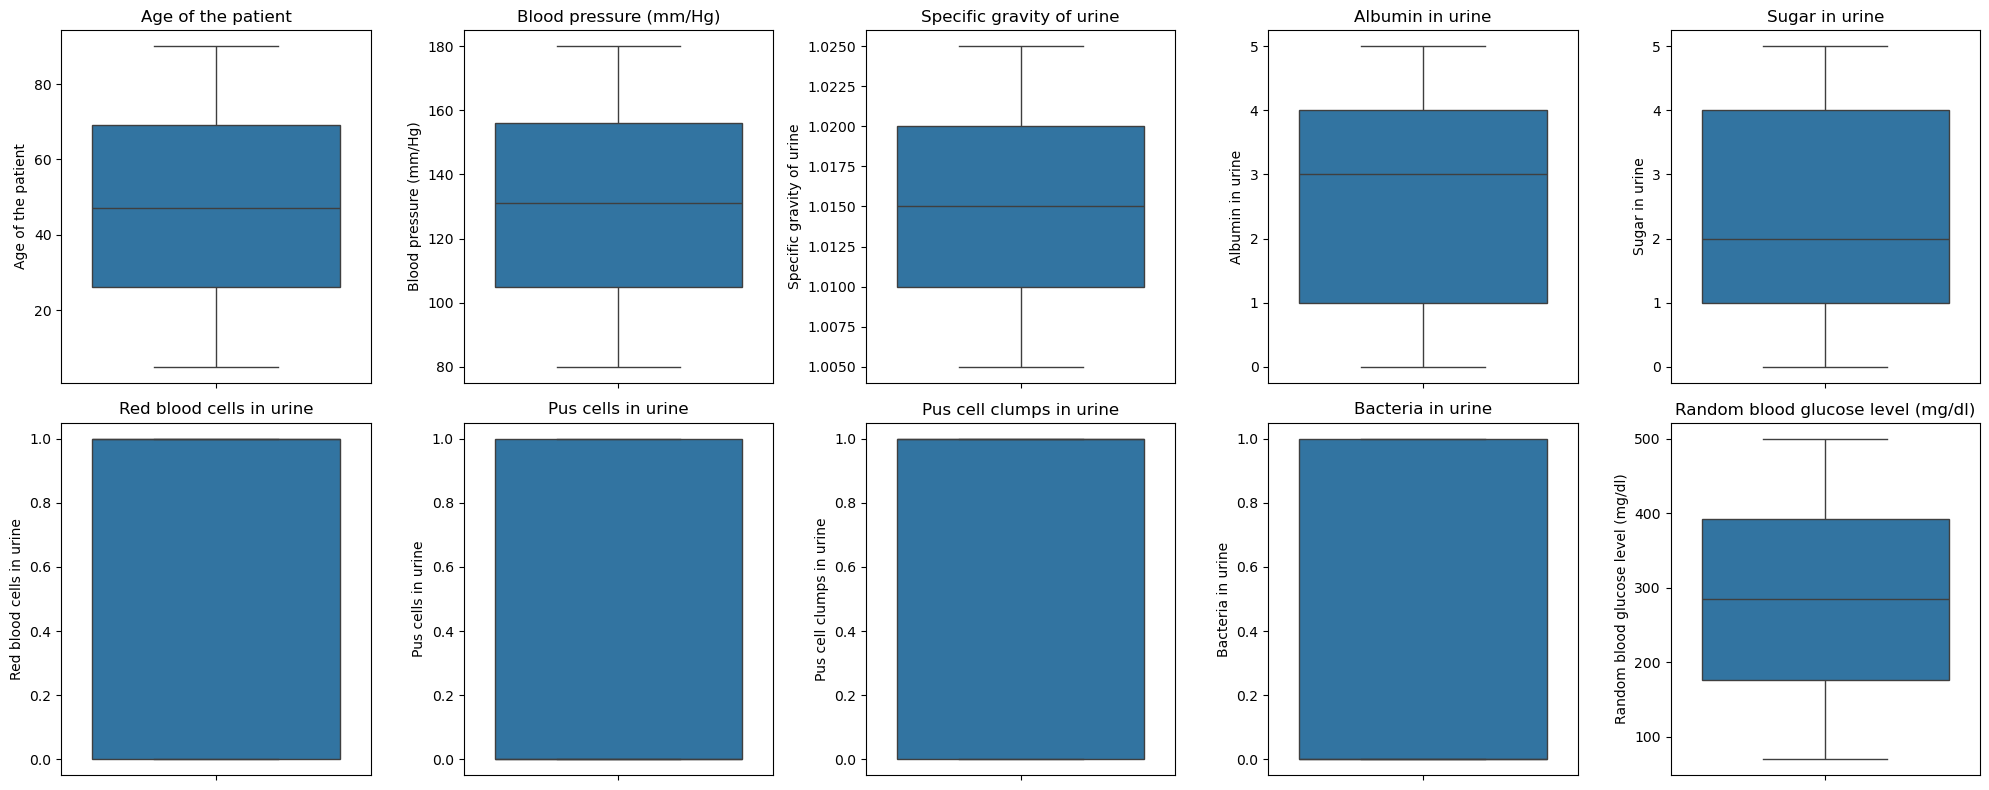

In [17]:
plt.figure(figsize=(20,8))

for i,col in enumerate(num_cols[:10],1):
    plt.subplot(2,5,i)
    sns.boxplot(y=kd[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [18]:
res=kd.select_dtypes(include=['int64','float64']).corr()

In [19]:
res>0.8

,Age of the patient,Blood pressure (mm/Hg),Specific gravity of urine,Albumin in urine,Sugar in urine,Red blood cells in urine,Pus cells in urine,Pus cell clumps in urine,Bacteria in urine,Random blood glucose level (mg/dl),...,Smoking status,Body Mass Index (BMI),Physical activity level,Duration of diabetes mellitus (years),Duration of hypertension (years),Cystatin C level,Urinary sediment microscopy results,C-reactive protein (CRP) level,Interleukin-6 (IL-6) level,Target
Age of the patient,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
Blood pressure (mm/Hg),False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
Specific gravity of urine,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
Albumin in urine,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
Sugar in urine,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
Red blood cells in urine,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
Pus cells in urine,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
Pus cell clumps in urine,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
Bacteria in urine,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
Random blood glucose level (mg/dl),False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


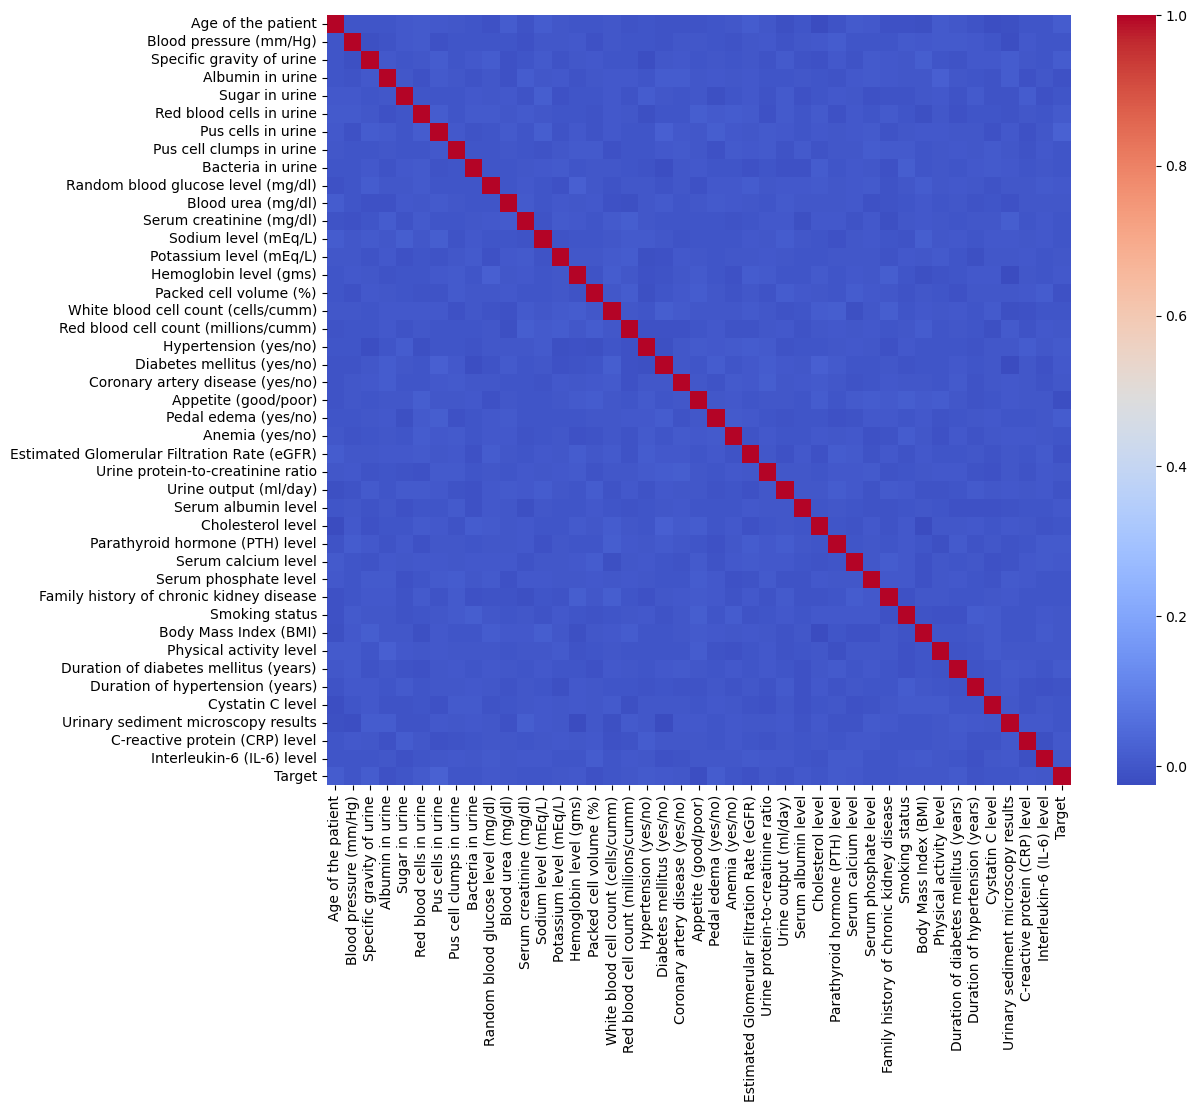

In [20]:
plt.figure(figsize=(12,10))
sns.heatmap(res, cmap='coolwarm')
plt.show()

In [21]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

X = kd.drop('Target', axis=1)
y = kd['Target']

model = RandomForestClassifier(random_state=42)

selector = RFE(estimator=model, n_features_to_select=15)

X_rfe = selector.fit_transform(X, y)

selected_features = X.columns[selector.support_]

print("Selected Features:")
print(selected_features)

Selected Features:
Index(['Random blood glucose level (mg/dl)', 'Blood urea (mg/dl)',
       'Serum creatinine (mg/dl)', 'Sodium level (mEq/L)',
       'Potassium level (mEq/L)', 'White blood cell count (cells/cumm)',
       'Estimated Glomerular Filtration Rate (eGFR)',
       'Urine protein-to-creatinine ratio', 'Urine output (ml/day)',
       'Parathyroid hormone (PTH) level', 'Serum calcium level',
       'Serum phosphate level', 'Body Mass Index (BMI)',
       'C-reactive protein (CRP) level', 'Interleukin-6 (IL-6) level'],
      dtype='object')


In [22]:
kd['Target'].value_counts()

Target
3    16432
1     2054
2      821
0      821
4      410
Name: count, dtype: int64

In [23]:
ranking = pd.DataFrame({
    'Feature': X.columns,
    'Rank': selector.ranking_
}).sort_values(by='Rank')

print(ranking)

                                        Feature  Rank
12                         Sodium level (mEq/L)     1
11                     Serum creatinine (mg/dl)     1
10                           Blood urea (mg/dl)     1
13                      Potassium level (mEq/L)     1
9            Random blood glucose level (mg/dl)     1
30                          Serum calcium level     1
26                        Urine output (ml/day)     1
16          White blood cell count (cells/cumm)     1
31                        Serum phosphate level     1
25            Urine protein-to-creatinine ratio     1
24  Estimated Glomerular Filtration Rate (eGFR)     1
29              Parathyroid hormone (PTH) level     1
40               C-reactive protein (CRP) level     1
41                   Interleukin-6 (IL-6) level     1
34                        Body Mass Index (BMI)     1
28                            Cholesterol level     2
38                             Cystatin C level     3
27                          

In [24]:
X_selected = X[selected_features]
y = kd['Target']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

In [26]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [29]:
model = RandomForestClassifier(random_state=42)

model.fit(X_train_smote, y_train_smote)

RandomForestClassifier(random_state=42)

In [30]:
pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.7164070107108081
              precision    recall  f1-score   support

           0       0.03      0.01      0.02       164
           1       0.10      0.07      0.08       411
           2       0.03      0.02      0.02       164
           3       0.80      0.89      0.84      3287
           4       0.00      0.00      0.00        82

    accuracy                           0.72      4108
   macro avg       0.19      0.20      0.19      4108
weighted avg       0.65      0.72      0.68      4108



In [31]:
joblib.dump(model,"kidney_disease_model.pkl")

['kidney_disease_model.pkl']